Import Dependencies & Global Parameter Configuration

In [172]:
# sudo apt-get install -y gcc python3-dev

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import re
import pygraphviz


from pathlib import Path
from scipy.stats import pearsonr
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.font_manager as fm
from networkx.utils import UnionFind
from networkx.drawing.nx_agraph import graphviz_layout
from collections import Counter
from matplotlib.colors import Normalize,LinearSegmentedColormap

In [174]:
# Define function
def load_and_validate_data(file_path,test):
    """
    Load cell-correlation CSV data and validate format integrity:
    - First row/column are cell IDs (starting from 0, contiguous numbering)
    - Data matrix must be square (same number of rows and columns)
    """
    try:
        # Read CSV (first column as index = cell IDs, first row as column names = cell IDs)
        data = pd.read_csv(file_path, header=0, index_col=0)

        # Basic validation: ensure data is not empty
        if data.empty:
            raise ValueError("Data is empty. Please check CSV file content.")
        if test == 'test1':
            celltype_info = data['celltype']
            data = data.drop(columns = 'celltype')
        # Extract cell IDs and cast to int (ensure ID format is valid)
        row_ids = data.index.values  # Row IDs (first column)
        col_ids = data.columns.values  # Column IDs (first row)
        print(np.array(row_ids, dtype=np.float64).round().astype(int))
        try:
            row_ids_int = np.array(row_ids, dtype=np.float64).round().astype(int)
            col_ids_int = np.array(col_ids, dtype=np.float64).round().astype(int)
        except ValueError:
            raise ValueError("Cell IDs must be integer format (e.g., 0,1,2...).")

        # Critical validation: row/column IDs must match and matrix must be square
        if data.shape[0] != data.shape[1]:
            raise ValueError(f"Correlation matrix must be square; current shape is {data.shape[0]}x{data.shape[1]}.")
        

        # Validation passed, return results
        if VERBOSE:
            print(f"✅ Data loaded successfully: {len(row_ids)} cells, matrix shape {data.shape[0]}x{data.shape[1]}")
        if test =='test1':
            return data,(row_ids,celltype_info)
        else:
            return data, ids  # data=correlation matrix, row_ids=cell ID list

    except Exception as e:
        print(f"❌ Data loading failed: {str(e)}")
        raise  # Re-raise error for easier debugging

In [175]:
def plot_significant_total_ratio(data, alpha):#therehol test is abanded
    # selected upper trangle data
    print('Running significance filtering:')
    upper_triangle_indices = np.triu_indices_from(data, k=1)
    linear_data = data.values[upper_triangle_indices]
    mean = np.mean(linear_data)
    std = np.std(linear_data)
    # significance test(FDR)
    z_scores = stats.zscore(linear_data)  # Compute Z-scores automatically
    plt.hist(z_scores, bins=50, alpha=0.7, color='blue')
    plt.title('Z-score Distribution')
    plt.xlabel('Z-score')
    
    # Compute right-tail p-values
    p_values = stats.norm.sf(z_scores)
    print(f'Min p-value {min(p_values)}, max p-value {max(p_values)}')
    # Significance mask
    mask = p_values < alpha
    #mask,corrected_p,_,_= multipletests(p_values, alpha=0.05, method='fdr_bh')
    sig_counts = []
    edge_counts = []


    # Compute non-significant connections on the left tail
    survived = linear_data[mask]
    print(survived)

    mask_2d = np.zeros((data.shape[0], data.shape[0]), dtype=bool)

# Map the linear mask to the upper-triangular part of the 2D matrix
    mask_2d[np.triu_indices_from(data, k=1)] = mask

    # Now mask_2d can be used to index the original matrix
    mask_2d = mask_2d | mask_2d.T
        
    return mask_2d,mask,p_values


In [176]:
def  plot_thershold(data,threshold):
     print('Running threshold filtering:')
     upper_triangle_indices = np.triu_indices_from(data, k=1)
     linear_data = data.values[upper_triangle_indices]
     plt.hist(linear_data, bins=50, color='skyblue', edgecolor='black')
     plt.axvline(x=threshold, color='red', linestyle='--', label=f'Treshold = {threshold}')
     plt.title('Correlation Coefficient Distribution')
     plt.xlabel('Correlation Coefficient')
     plt.ylabel('Frequency')
     plt.show()
     # significance test(FDR)
     # Compute Z-scores automatically
     mask = linear_data >= threshold
     #mask,corrected_p,_,_= multipletests(p_values, alpha=0.05, method='fdr_bh')
     # Compute non-significant connections on the left tail
     mask_2d = np.zeros((data.shape[0], data.shape[0]), dtype=bool)

# Map the linear mask to the upper-triangular part of the 2D matrix
     mask_2d[np.triu_indices_from(data, k=1)] = mask

    # Now mask_2d can be used to index the original matrix
     mask_2d = mask_2d | mask_2d.T
        
     return mask_2d,mask


In [177]:
def find_Threshold(lst):
    indices = [i for i, value in enumerate(lst) if value == 1]
    if indices:
        return indices[0]  # Return the first index where value is 1
    else:
        return max(lst)

In [178]:
def binarize_matrix(matrix, mask):
    """
    Binarize the correlation matrix:
    - correlation > threshold -> 1 (keep connection)
    - correlation <= threshold -> 0 (remove connection)
    - set diagonal to 0 (no self-connection)
    """
    if VERBOSE:
        print(f"\n⚙️  Binarizing matrix using significance values...")
    # Copy matrix to avoid modifying original data
    binary_matrix = matrix.copy()
    
    # Apply threshold
    binary_matrix[mask ==True] = 1
    binary_matrix[mask == False] = 0
    
    # Set diagonal to 0 (self-connections are invalid)
    np.fill_diagonal(binary_matrix, 0)
    
    # Count valid edges (undirected graph: each edge counted twice, divide by 2)
    total_edges = int(np.sum(binary_matrix) / 2)
    if VERBOSE:
        print(f"✅ Binarization complete. Network contains {total_edges} valid edges")
    
    return binary_matrix



In [179]:
def get_weight_matrix(matrix, mask):
    weight_matrix = matrix.copy()
    
    # 1. Valid connections: weight = absolute correlation coefficient (connection strength)
    # 2. Invalid connections: weight = 0 (no connection where mask is False)
    weight_matrix[~mask] = 0  # Set invalid-connection weights to 0
    
    # 3. Set diagonal to 0 (cells do not connect to themselves)
    np.fill_diagonal(weight_matrix, 0)
    return weight_matrix

In [180]:
def analyze_network(adjacency_matrix, cell_ids):
    """
    Analyze network topology based on the adjacency matrix:
    - Node-level metrics: degree, clustering coefficient, betweenness centrality
    - Network-level metrics: number of connected components, characteristic path length of largest component
    """
    try:
        if VERBOSE:
            print("\n🔬 Starting network topology analysis...")
        
        # 1. Build an undirected graph (use cell IDs as node labels)
        G = nx.from_numpy_array(adjacency_matrix, create_using=nx.Graph())
        G = nx.relabel_nodes(G, {i: cell_id for i, cell_id in enumerate(range(len(cell_ids)))})
        
        
        # 2. Compute network-level metrics (global network properties)
        connected_components = list(nx.connected_components(G))  # All connected components
        num_components = len(connected_components)  # Number of connected components
        components_len = [len(c) for c in connected_components]
        component_map = {}  # Size of each component
        for comp_id, component in enumerate(connected_components):
            for node in component:
                component_map[node] = (comp_id, components_len[comp_id])

        # 3. Compute node-level metrics (per-cell properties)
        node_df = pd.DataFrame({
            "Cell_ID": list(G.nodes),
            "Clustering_Coefficient": list(nx.clustering(G).values()),  # Clustering coefficient
            "Degree": [deg for _, deg in G.degree()],  # Degree
            "Betweenness_Centrality": list(nx.betweenness_centrality(G).values()), # Betweenness centrality
            "Component": [component_map[node][0] for node in G.nodes],
            "Component_length": [component_map[node][1] for node in G.nodes]   # Belonging connected component
        })
        
        
        # Characteristic path length of the largest component (information transfer efficiency)
        if connected_components:
            max_comp_nodes = max(connected_components, key=len)
            G_max_comp = G.subgraph(max_comp_nodes)
            # if len(max_comp_nodes) > 1:
            #     # Compute shortest paths for all node pairs
            #     shortest_paths = dict(nx.all_pairs_shortest_path_length(G_max_comp))
            #     path_lengths = [shortest_paths[u][v] for u in G_max_comp.nodes() for v in G_max_comp.nodes() if u != v]
            #     char_path_length = np.mean(path_lengths)
            # else:
            #     char_path_length = 0.0  # No path for a single-node graph
        else:
            max_comp_nodes = []
            char_path_length = 0.0
        
        # Aggregate network-level metrics
        network_df = pd.DataFrame([{
            "Total_Nodes": G.number_of_nodes(),
            "Total_Edges": G.number_of_edges(),
            "Total_Components": num_components,
            "Components_Lengths": np.sort(components_len),
            "Max_Component_Size": len(max_comp_nodes),
        }])

        if VERBOSE:
            print("✅ Network analysis completed. Key metrics:")
            for value in network_df.columns:
                print(f"{value}: {network_df.iloc[0][value]}")

        return G, node_df, network_df  # Return graph object, node metrics, and network metrics

    except Exception as e:
        print(f"❌ Network analysis failed: {str(e)}")
        raise


In [181]:
def spanning_forest_unweighted(G):
    sf = nx.Graph()
    sf.add_nodes_from(G.nodes())
    uf = UnionFind(G.nodes())
    for u, v in G.edges():
        if uf[u] != uf[v]:
            sf.add_edge(u, v)
            uf.union(u, v)
    return sf

In [182]:
def minimum_spanning_forest_weighted(G):
    """Generate a minimum spanning forest for a weighted undirected graph."""
    msf = nx.Graph()
    msf.add_nodes_from(G.nodes())  # Keep all nodes
    
    # Build an MST for each connected component
    for component in nx.connected_components(G):
        subgraph = G.subgraph(component)
        # Use Kruskal algorithm to build MST (smaller weights are preferred)
        mst = nx.minimum_spanning_tree(subgraph, weight='weight')
        msf.add_edges_from(mst.edges(data=True))  # Preserve edge weight attributes
    return msf

In [183]:
def find_key_cells(node_metrics, top_n=10):
    """
    Select key cells in the network:
    - Sort by betweenness centrality (hub cells controlling information flow)
    - Sort by degree (high-connectivity cells in core network positions)
    """
    if VERBOSE:
        print(f"\n🔍 Selecting key cells in the network (top {top_n})...")
    
    # 1. Filter by betweenness centrality (hub cells)
    betweenness_sorted = sorted(
        node_metrics["Betweenness_Centrality"].items(),
        key=lambda x: x[1], reverse=True
    )[:top_n]
    betweenness_top = pd.DataFrame({
        "Cell_ID": [cid for cid, val in betweenness_sorted],
        "Betweenness_Centrality": [round(val, 4) for cid, val in betweenness_sorted],
        "Degree": [node_metrics["Degree"][cid] for cid, val in betweenness_sorted]
    })
    
    # 2. Filter by degree (high-connectivity cells)
    degree_sorted = sorted(
        node_metrics["Degree"].items(),
        key=lambda x: x[1], reverse=True
    )[:top_n]
    degree_top = pd.DataFrame({
        "Cell_ID": [cid for cid, val in degree_sorted],
        "Degree": [val for cid, val in degree_sorted],
        "Clustering_Coefficient": [round(node_metrics["Clustering_Coefficient"][cid], 4) for cid, val in degree_sorted]
    })
    
    return betweenness_top, degree_top


In [184]:
# def R2ized_matrix(matrix,theresold):
#     r2_matrix = np.zeros_like(matrix)
# # find R2
#     for i in range(matrix.shape[0]):
#         for j in range(matrix.shape[1]):
#             if i != j:  # Ignore diagonal elements
#                 # Independent variable: all elements in row i
#                 x = matrix.iloc[i, :].values.reshape(-1, 1)
#                 # Dependent variable: all elements in column j
#                 y = matrix.iloc[:, j].values

#                 # Run linear regression
#                 model = LinearRegression()
#                 model.fit(x, y)
#                 y_pred = model.predict(x)
#                 r2 = r2_score(y, y_pred)
#                 # Store R² value in matrix
#                 r2_matrix[i, j] = r2
#             else:
#                 r2_matrix[i, j] = 1
#     r2_df = pd.DataFrame(r2_matrix, index=matrix.index, columns=matrix.columns)
#     # Count valid edges
#     sig_matrix = np.zeros_like(matrix)
#     sig_matrix[ r2_df > theresold] = 1
#     sig_df = pd.DataFrame(sig_matrix, index=matrix.index, columns=matrix.columns)
#     total_edges = int(np.sum(sig_matrix) / 2)
#     print(f"✅ Binarization complete! Network contains {total_edges} valid edges")
#     return sig_matrix

# R2_mat = R2ized_matrix(data,0.1)
# R2_mat

In [185]:
# 1. filepath
#LHQ30,LHQ50,LH5799,LH5798,LH5779,LH0167,LH0166
#CSDS5797,,CSDSQ29,CSDSQ27,CSDSQ26,CSDS5776,CSDS0370

global VERBOSE
VERBOSE =  True  # Whether to print detailed runtime logs
projectpath = 'g:\\XJN_M2project'
ids = [  #"CSDS5797" ]  # empty line for test
    "LHQ30", "LHQ50", "LH5799", "LH5798", "LH5779", "LH0167", "LH0166",
    "CSDS5797", "CSDSQ29", "CSDSQ27", "CSDSQ26", "CSDS5776", "CSDS0370"
]
conditions = ['pre', 'post', 'rescue']
test = 'test1'

Getting network metrics for S_to_I


[ 0  1  2 ... 96 97 98]
✅ 数据加载成功！共2201个细胞，矩阵维度2201×2201
进行阈值筛选:


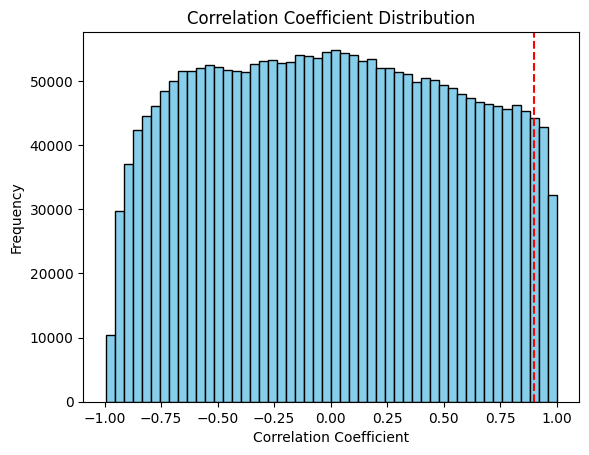


🔬 开始网络拓扑属性分析...
✅ 网络分析完成！关键指标：
Total_Nodes: 2201
Total_Edges: 97417
Total_Components: 636
Components_Lengths: [   1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1    1    1    1    1    1    1    1
    1    1    1    1    1    1    1  

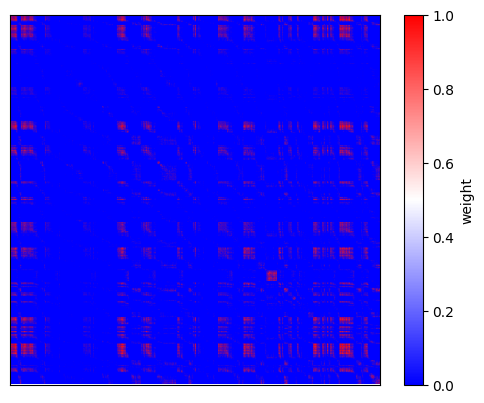

In [186]:

event_type = 'S_to_I'#S_to_I,I_to_S

alpha = 0.04
threshold = 0.9

INPUT_FILE_PATH = os.path.join(projectpath,'correlation_analysis', test, f'{event_type}_correlation_matrix.csv')
if not os.path.exists(INPUT_FILE_PATH):
    print(f"WARNING: Input file not found: {INPUT_FILE_PATH}")
print(f'Getting network metrics for {event_type}')
OUTPUT_FILE_PATH = os.path.join(projectpath ,'correlation_analysis', test , f'{event_type}_network_metrics_result.csv')
# notebook output
SHOW_VISUALIZATION = True  # Whether to show visualization plots

# Data loading and validation
data, id_info = load_and_validate_data(INPUT_FILE_PATH,test)
if test == 'test1':
    cell_ids = id_info[0]
else:
    cell_ids = id_info
# Select threshold
mask_2d,mask = plot_thershold(data, threshold)
plt.close('all')


# Define binarized matrix (threshold-based binarization)
weight_matrix = get_weight_matrix(data.values, mask_2d)
plt.imshow(weight_matrix,cmap='bwr')
plt.colorbar(label='weight')# Add label for colorbar
plt.xticks([])  # Clear x-axis ticks
plt.yticks([])
# Network analysis (compute topological metrics) #
G, node_df, network_df = analyze_network(weight_matrix, cell_ids)


In [187]:
cell_type_id = id_info[1].reset_index(drop=True).to_frame()

if not 'celltype' in node_df.columns:
    node_df = pd.concat([node_df,cell_type_id],axis=1)
# Key-cell filtering and analysis
betweenness_top10, degree_top10 = find_key_cells(node_df, top_n=10)

print("="*60)
print("          Key Cell Selection Results")
print("="*60)
print(f"\n1. Top 10 hub cells by betweenness centrality (information-flow control):")
print(betweenness_top10.to_string(index=False))

print(f"\n2. Top 10 high-degree cells (core network positions):")
print(degree_top10.to_string(index=False))

key_cells_df = pd.DataFrame({
    "Hub_Cell_ID": betweenness_top10["Cell_ID"],
    "Hub_Betweenness": betweenness_top10["Betweenness_Centrality"],
    "High_Degree_Cell_ID": degree_top10["Cell_ID"],
    "High_Degree_Value": degree_top10["Degree"]
})


# Result saving and summary plots
# node_df.to_csv(OUTPUT_FILE_PATH, index=False, encoding="utf-8-sig")
# key_cells_path = Path(OUTPUT_FILE_PATH).parent / "key_cells.csv"
# key_cells_df.to_csv(key_cells_path, index=False, encoding="utf-8-sig")


🔍 筛选网络中的关键细胞（前10个）...
          网络关键细胞筛选结果

1. 介数中心性前10的枢纽细胞（控制信息传递）：
 Cell_ID  Betweenness_Centrality  Degree
    1036                  0.1518      27
    2152                  0.0893      72
    2096                  0.0786      22
    1756                  0.0776      12
    1459                  0.0639      18
    1613                  0.0574       9
    1686                  0.0547      17
    2047                  0.0542      18
    1747                  0.0527      17
     786                  0.0516       5

2. 度前10的高连接细胞（网络核心位置）：
 Cell_ID  Degree  Clustering_Coefficient
      27     419                  0.7543
     661     418                  0.7298
     662     417                  0.7489
    2032     417                  0.7359
      81     415                  0.7488
     670     414                  0.7551
    1001     414                  0.7675
    1265     414                  0.7706
    1963     414                  0.7647
    1972     414                  0.7700


In [188]:
node_df

,Cell_ID,Clustering_Coefficient,Degree,Betweenness_Centrality,Component,Component_length,celltype
0,0,0.776391,400,0.000374,0,1544,1
1,1,0.890441,149,0.000096,0,1544,1
2,2,0.772748,271,0.001148,0,1544,1
3,3,0.000000,0,0.000000,1,1,1
4,4,0.899643,295,0.000098,0,1544,1
...,...,...,...,...,...,...,...
2196,2196,0.517659,147,0.002246,0,1544,4
2197,2197,0.602621,111,0.000580,0,1544,4
2198,2198,0.700560,85,0.000119,0,1544,4
2199,2199,0.537287,131,0.002492,0,1544,4


PLOTTING

C:\Users\Tony.S\AppData\Local\Temp\ipykernel_24772\2235438264.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to g:\XJN_M2project\correlation_analysis\test1\S_to_I_correaltion_graph.pdf


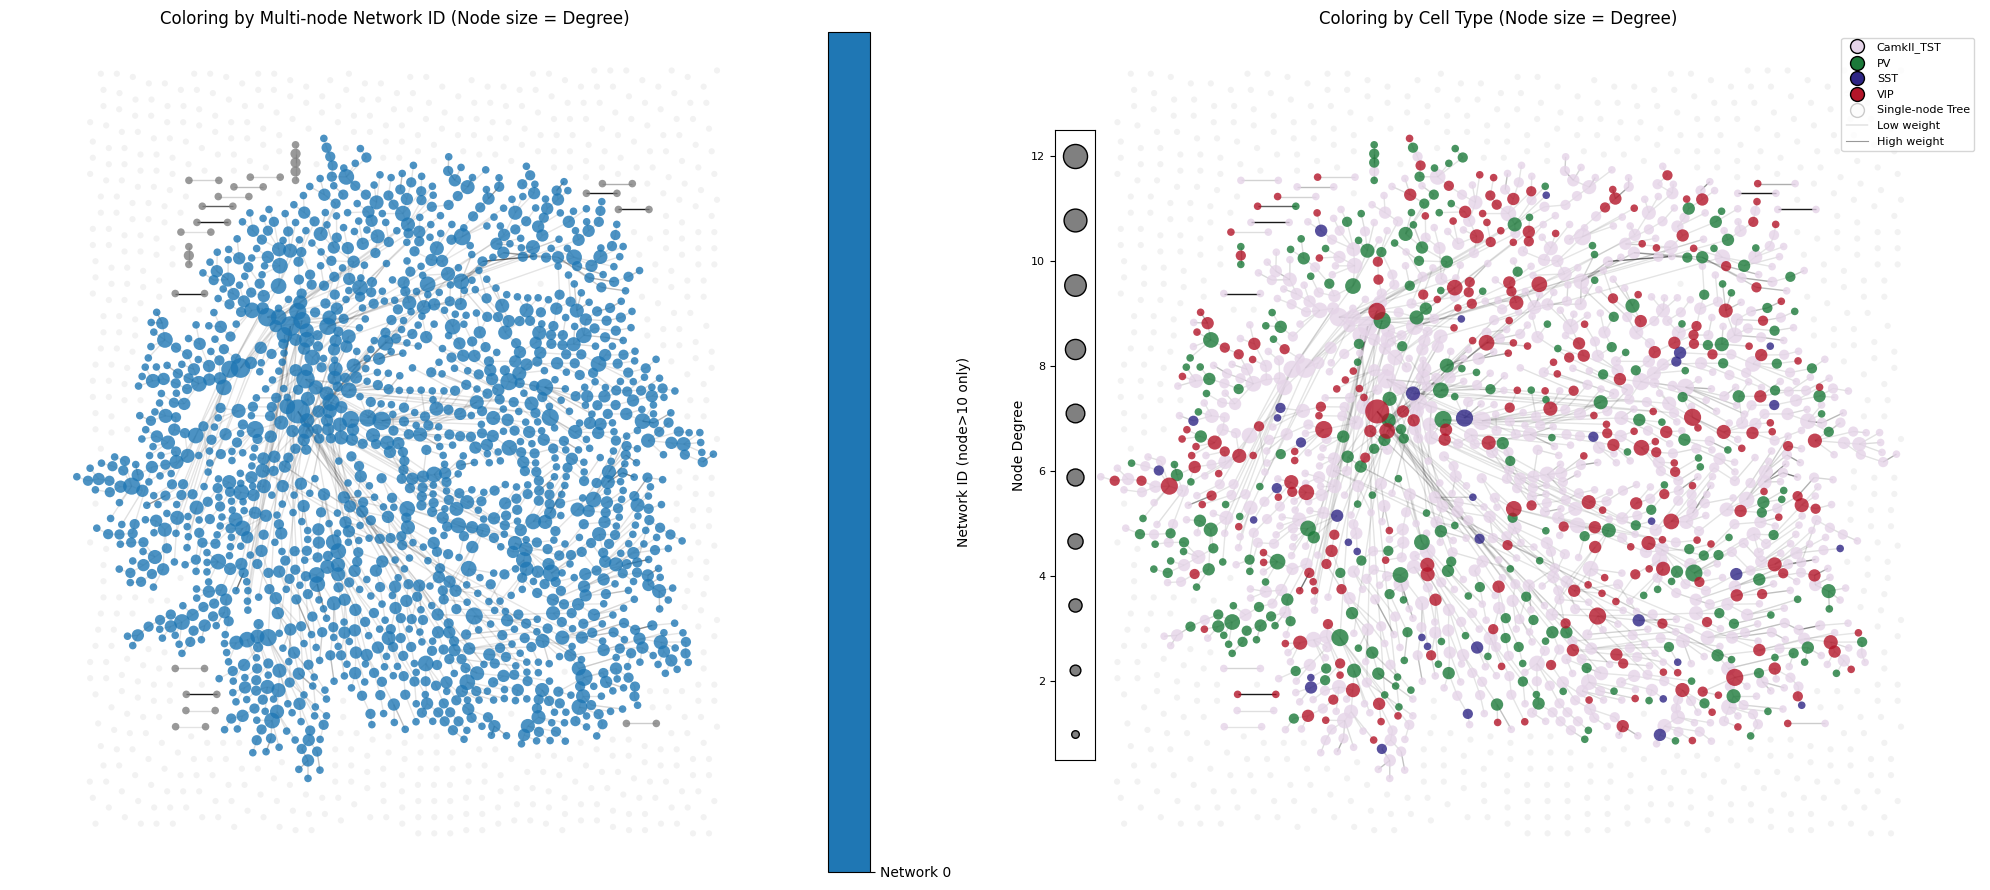

生成森林包含 636 棵树
其中单节点树 617 棵，多节点树 1 棵
边权重统计：均值=0.3167，范围=[0.3000, 0.8000]
多节点度值统计：均值=1.98，范围=[1, 12]


In [189]:

# 1. Data preparation and graph construction
n_neurons = weight_matrix.shape[0]
cell_types = node_df['celltype'].values

# Build weighted graph
G = nx.Graph()
G.add_nodes_from(range(n_neurons))
for i in range(n_neurons):
    for j in range(i+1, n_neurons):
        if (w := weight_matrix[i, j]) != 0:
            G.add_edge(i, j, weight=w)

# Build forest and analyze components
sf = minimum_spanning_forest_weighted(G)
sf_components = list(nx.connected_components(sf))
multi_node_components = [c for c in sf_components if len(c) > 10]

# Map multi-node network IDs
multi_node_id_map = {n: i for i, comp in enumerate(multi_node_components) for n in comp}
node_tree_id = [multi_node_id_map.get(n, -1) for n in sf.nodes()]

# 2. Network metric calculation
G_components = list(nx.connected_components(G))
comp_info = {n: (i, len(c)) for i, c in enumerate(G_components) for n in c}


# Largest connected component processing
max_comp_nodes = max(G_components, key=len) if G_components else []

# 3. Node style configuration
lonely_node_ids = set(n for c in G_components if len(c)==1 for n in c)
node_degrees = dict(sf.degree())

# Node size calculation
min_size, max_size, fixed_single_size = 30, 300, 20
multi_degs = [d for n, d in node_degrees.items() if n not in lonely_node_ids]

if multi_degs:
    min_d, max_d = min(multi_degs), max(multi_degs)
    node_sizes = [fixed_single_size if n in lonely_node_ids else 
                 min_size + (max_size - min_size)*(d - min_d)/(max_d - min_d + 1e-8)
                 for n, d in node_degrees.items()]
else:
    node_sizes = [fixed_single_size] * len(node_degrees)

# Coloring scheme
cmap_tree = plt.cm.tab10
node_colors_id = ['gray' if tid == -1 else cmap_tree(tid % cmap_tree.N) 
                 for tid in node_tree_id]

color_map_cell = {1: '#E5D4E8', 2: '#1B7939', 3: '#2E2585', 4: '#B31529'}
node_colors_cell = ['gray' if n in lonely_node_ids else color_map_cell[cell_types[n]]
                   for n in sf.nodes()]

edges = sf.edges(data=True)
weights = [d['weight'] for u, v, d in edges]
min_weight = np.min(weights)
max_weight = np.max(weights)
weights = [((n-min_weight)/(max_weight-min_weight))*0.5+0.3 for n in weights] # Normalize weights to the 0.3-0.8 range
cmap = plt.cm.Greys

alphas = [0.1 if n in lonely_node_ids else 0.8 for n in sf.nodes()]

line_alphas = []

for i, (u, v, corr_val) in enumerate(edges):
            normalized = (corr_val['weight'] - min_weight) / (max_weight - min_weight)
            alpha = 0.1 + 0.8 * normalized  # Map to the 0.1-0.9 range
            line_alphas.append(alpha)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
pos = graphviz_layout(sf, prog='twopi', args='-Goverlap=prism -Gnodesep=200')

# Subplot 1: color by network ID
nx.draw_networkx_nodes(sf, pos, ax=ax1, node_size=node_sizes, node_color=node_colors_id,
                      edgecolors='none', alpha=alphas, linewidths=alphas)
nx.draw_networkx_edges(sf, pos, ax=ax1, edge_color='black', alpha=line_alphas)

# Add colorbar
if (n_multi := len(multi_node_components)) > 0:
    used_ids = range(min(n_multi, cmap_tree.N))
    sm = plt.cm.ScalarMappable(cmap=mpl.colors.ListedColormap([cmap_tree(i) for i in used_ids]))
    cbar = plt.colorbar(sm, ax=ax1, ticks=used_ids)
    cbar.set_ticklabels([f'Network {i}' for i in used_ids])
    cbar.set_label('Network ID (node>10 only)', fontsize=10)
else:
    ax1.text(0.5, 0.5, 'No multi-node networks', ha='center', va='center', transform=ax1.transAxes)

ax1.set_title('Coloring by Multi-node Network ID (Node size = Degree)', fontsize=12)
ax1.axis('off')

# Subplot 2: color by cell type
nx.draw_networkx_nodes(sf, pos, ax=ax2, node_size=node_sizes, node_color=node_colors_cell,
                      edgecolors='none', alpha=alphas, linewidths=alphas)
nx.draw_networkx_edges(sf, pos, ax=ax2, edge_color='black', alpha=line_alphas)

# Legend
cellnames = ['CamkII_TST','PV','SST','VIP']
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=cellnames[i],
              markerfacecolor=c, markersize=10, markeredgecolor='black')
    for i, c in enumerate(color_map_cell.values())
] + [
    plt.Line2D([0], [0], marker='o', color='w', label='Single-node Tree',
              markerfacecolor='#F0F0F0', markersize=10, markeredgecolor='black', alpha=0.2),
    plt.Line2D([0,1], [0,0], color='#999999', linewidth=min(weights), label='Low weight'),
    plt.Line2D([0,1], [0,0], color='#999999', linewidth=max(weights), label='High weight'),
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=8)
ax2.set_title('Coloring by Cell Type (Node size = Degree)', fontsize=12)
ax2.axis('off')

# Reference colorbar for node size
if multi_degs:
    cax = fig.add_axes([0.53, 0.15, 0.02, 0.7])
    for s, d in zip(np.linspace(min_size, max_size, 10), np.linspace(min_d, max_d, 10)):
        cax.scatter([0], [d], s=s, color='gray', edgecolors='black')
    cax.set(ylim=(min_d-0.5, max_d+0.5), xlim=(-0.5, 0.5), xticks=[], ylabel='Node Degree')
    cax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(Path(OUTPUT_FILE_PATH).parent,f'{event_type}_correaltion_graph.pdf'))
print(f'Figure saved to {os.path.join(Path(OUTPUT_FILE_PATH).parent,f"{event_type}_correaltion_graph.pdf")}')
plt.show()

# 5. Output statistics
print(f"Generated forest contains {len(G_components)} trees")
print(f"Single-node trees: {len([c for c in G_components if len(c)==1])}; multi-node trees: {n_multi}")
if 'weights' in locals() and weights:
    print(f"Edge-weight stats: mean={np.mean(weights):.4f}, range=[{min(weights):.4f}, {max(weights):.4f}]")
if multi_degs:
    print(f"Multi-node degree stats: mean={np.mean(multi_degs):.2f}, range=[{min_d}, {max_d}]")


Number of neurons after processing: 2201
Cell type distribution: [   0 1516  341   47  297]
Adjacency matrix shape: (2201, 2201)

⚙️  使用显著值进行矩阵二值化...
✅ 二值化完成！网络共包含97417条有效连接


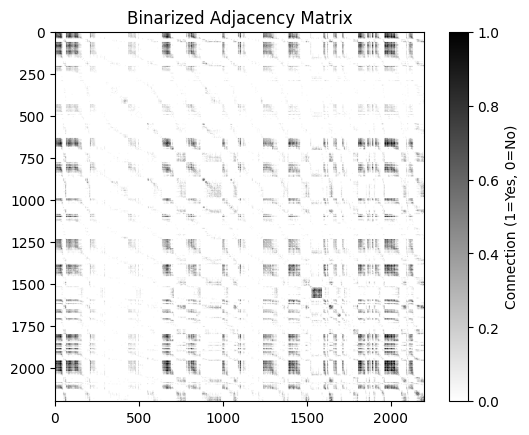

Weight matrix value distribution: positive=50978, negative=30798, zero=4762625


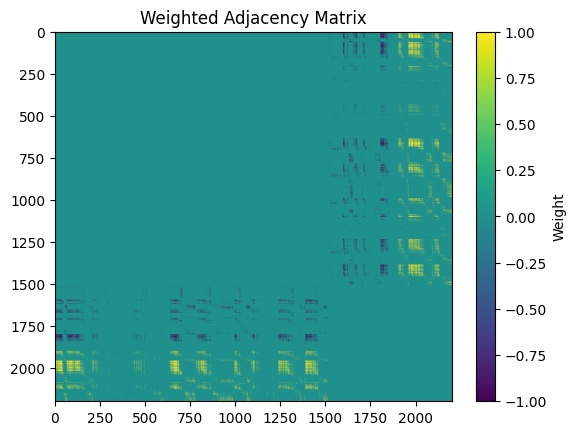

Number of graph nodes: 2201, number of edges: 97417
Number of connected components: 636
Node value range: [-31.00, 48.00]
Node degree range: [0, 419]


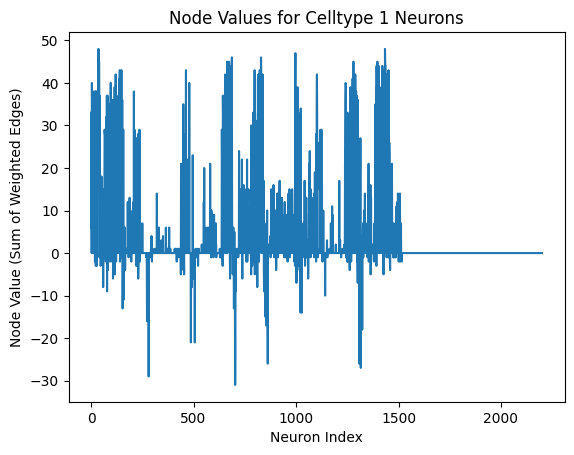

In [190]:
from matplotlib.colors import Normalize

# Process data as required (CamkII <-> PV (inhibitory), CamkII <-> VIP (disinhibitory), SST excluded)
n_neurons = len(cell_types)


# Debug info: Print basic data information
print(f"Number of neurons after processing: {n_neurons}")
print(f"Cell type distribution: {np.bincount(cell_types)}")
print(f"Adjacency matrix shape: {adjacency_matrix.shape}")

# ------------------------------
# 2. Set edge weights based on cell types
# ------------------------------
adjacency_matrix = binarize_matrix(data.values,mask_2d)
plt.imshow(adjacency_matrix,cmap='gray_r')
plt.title('Binarized Adjacency Matrix')
plt.colorbar(label='Connection (1=Yes, 0=No)')
plt.show()

weighted_adj = np.zeros((n_neurons, n_neurons))  # Initialize weighted adjacency matrix

for i in range(n_neurons):
    for j in range(i, n_neurons):  # For undirected graph, process only upper triangle
        if i == j:
            weighted_adj[i, j] = 0  # Self-connection is 0
            continue
        
        # Only set weights for existing edges in 
        if adjacency_matrix[i, j] != 1:
            continue  # Skip non-significant edges
            
        # Set weights based on cell types
        type_i = cell_types[i]
        type_j = cell_types[j]
        
        if (type_i == 1 and type_j == 2) or (type_i == 2 and type_j == 1):
            weighted_adj[i, j] = -1
            weighted_adj[j, i] = -1  # Symmetric for undirected graph
        elif (type_i == 1 and type_j == 4) or (type_i == 4 and type_j == 1):
            weighted_adj[i, j] = 1
            weighted_adj[j, i] = 1  # Symmetric for undirected graph
        else:
            weighted_adj[i, j] = 0
            weighted_adj[j, i] = 0  # Other connections are 0

# Debug info: Print weight matrix statistics
print(f"Weight matrix value distribution: positive={np.sum(weighted_adj > 0)}, negative={np.sum(weighted_adj < 0)}, zero={np.sum(weighted_adj == 0)}")
plt.imshow(weighted_adj, cmap='viridis',aspect='auto')
plt.colorbar(label='Weight')
plt.title('Weighted Adjacency Matrix')
plt.show()
# ------------------------------
# 3. Create undirected graph
# ------------------------------
G = nx.Graph()
G.add_nodes_from(range(n_neurons))

# Add edges (based on unweighted adjacency matrix and calculated weights)
for i in range(n_neurons):
    for j in range(i+1, n_neurons):  # For undirected graph, avoid duplicate additions
        if adjacency_matrix[i, j] == 1:
            w = weighted_adj[i, j]
            G.add_edge(i, j, weight=w)

# Debug info: Print basic graph information
print(f"Number of graph nodes: {G.number_of_nodes()}, number of edges: {G.number_of_edges()}")

# ------------------------------
# 4. Network component analysis
# ------------------------------
G_components = list(nx.connected_components(G))
comp_info = {n: (i, len(c)) for i, c in enumerate(G_components) for n in c}

# Debug info: Print number of components
print(f"Number of connected components: {len(G_components)}")

# ------------------------------
# 5. Node attribute calculation
# ------------------------------
# Node value: sum of all surrounding weighted edges (only for celltype == 1)
node_values = np.zeros(n_neurons)
# Get indices of nodes with celltype == 1
for i in np.where(cell_types == 1)[0]:  # Only process nodes with celltype == 1
    node_values[i] = sum(weighted_adj[i, :]) # for j in range(n_neurons) if adjacency_matrix[i, j] == 1)

plt.plot(node_values)
plt.title('Node Values for Celltype 1 Neurons')
plt.xlabel('Neuron Index')
plt.ylabel('Node Value (Sum of Weighted Edges)')
# Node degree calculation
node_degrees = dict(G.degree())

# Debug info: Print node attribute statistics
print(f"Node value range: [{np.min(node_values):.2f}, {np.max(node_values):.2f}]")
print(f"Node degree range: [{min(node_degrees.values())}, {max(node_degrees.values())}]")

# ------------------------------
# 6. Node style configuration
# ------------------------------
# Identify isolated nodes
lonely_node_ids = set(n for c in G_components if len(c)==1 for n in c)

# Node size calculation
min_size, max_size, fixed_single_size = 30, 200, 20
multi_degs = [d for n, d in node_degrees.items() if n not in lonely_node_ids]

if multi_degs:
    min_d, max_d = min(multi_degs), max(multi_degs)
    node_sizes = [fixed_single_size if n in lonely_node_ids else 
                 min_size + (max_size - min_size)*(d - min_d)/(max_d - min_d + 1e-8)
                 for n, d in node_degrees.items()]
else:
    node_sizes = [fixed_single_size] * len(node_degrees)

#node color
global_vmin = -30    # Minimum of all values across both graphs
global_vmax = 80    # Maximum of all values across both graphs

# For each graph, use the GLOBAL range instead of per-graph min/max
sub_node_values = [node_values[i] for i in G.nodes()]
# Use global min/max for normalization (critical for consistency)
norm = Normalize(vmin=global_vmin, vmax=global_vmax)
# Calculate position of 0 in the GLOBAL range (for white alignment)
zero_pos = (0 - global_vmin) / (global_vmax - global_vmin)  # Now consistent across graphs
# Custom diverging colormap (same as before, but aligned to global range)
neg_index  = np.linspace(0,zero_pos,3)
diff = zero_pos - neg_index[1]
pos_index = np.linspace(zero_pos+diff,1,4)
colors = [
    (0.0, '#337fff'),                  # Dark blue (global min)
    (zero_pos-diff, '#e6efff'),      # Near white (before 0)
    (zero_pos, '#f2f2f2'),             # White (exactly 0)
    (zero_pos+diff, '#fffbe6'),      # Near white (after 0)
    (pos_index[1], '#ffecb3'),
    (pos_index[2], '#ffc107'),
    (1.0, '#ffa000')                   # Deep yellow (global max)
]
custom_cmap = LinearSegmentedColormap.from_list('custom_colormap', colors)

# Node colors (now using global normalization)
node_colors = [custom_cmap(norm(node_values[i])) for i in G.nodes()]
# Node colors: celltype ==1 uses value-based color, others use cell type colors
node_colors = []
for i in range(n_neurons):
    cell_type = cell_types[i]
    if cell_type == 1:
        # Use value-based color for CamkII
        node_colors.append(custom_cmap(norm(node_values[i])))
    else:
        # Use cell types color 
        node_colors.append(color_map_cell[cell_type])

# Edge style configuration
edges = G.edges(data=True)
positive_edges = [(u, v) for u, v, d in edges if d['weight'] > 0]
negative_edges = [(u, v) for u, v, d in edges if d['weight'] < 0]
neutral_edges = [(u, v) for u, v, d in edges if d['weight'] == 0]

# Edge weight visualization (line width)
weights = [abs(d['weight']) for u, v, d in edges]
if weights:
    min_weight, max_weight = min(weights), max(weights)
    # Normalize weights to 0.3-1.5 range
    edge_widths = [0.3 + 1.2*(w-min_weight)/(max_weight-min_weight + 1e-8) for w in weights]
else:
    edge_widths = []

# Transparency settings
alphas = [0.1 if (cell_types[n] != 1 or n in lonely_node_ids) else 1.0 for n in G.nodes()]


In [191]:
print(f'Saving node values to {os.path.join(Path(OUTPUT_FILE_PATH).parent,f"{event_type}_CamKII_energy_score.csv")}')
node_values.tofile(os.path.join(Path(OUTPUT_FILE_PATH).parent,f'{event_type}_CamKII_energy_score.csv'),sep=',')

Saving node values to g:\XJN_M2project\correlation_analysis\test1\S_to_I_CamKII_energy_score.csv


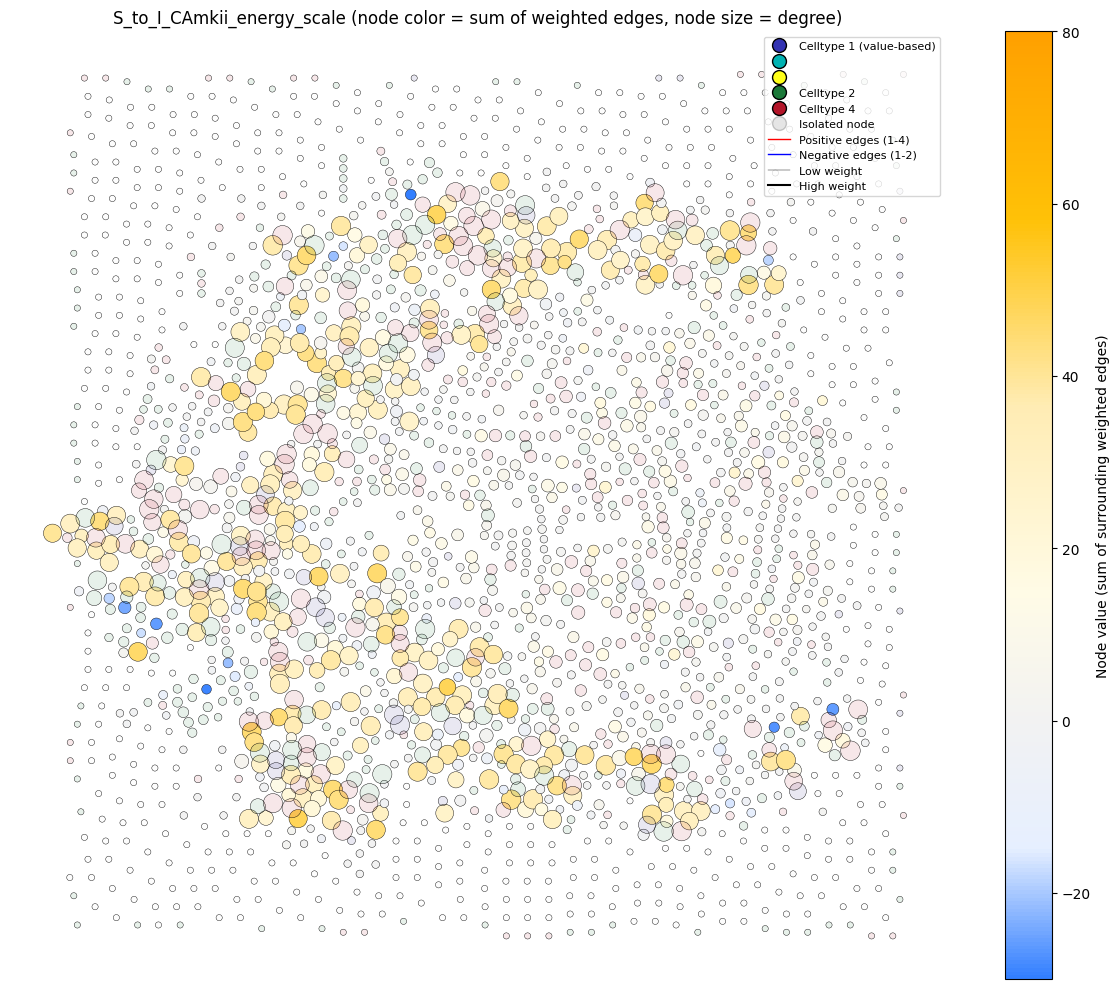


The network contains 636 connected components
Among them: 617 single-node components, 19 multi-node components
Edge weight statistics: mean=0.4197, range=[0.0000, 1.0000]
Node degree statistics: mean=123.00, range=[1, 419]


In [192]:

# ------------------------------
# 7. Visualization
# ------------------------------
np.random.seed(42)
fig, ax = plt.subplots(figsize=(12, 10))

# Use graphviz layout
# pos = graphviz_layout(G, prog='twopi', args='-Goverlap=prism -Gnodesep=200')

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                      edgecolors='black', alpha=alphas, linewidths=0.3)

# Draw edges (distinguish between positive and negative weights)
# nx.draw_networkx_edges(G, pos, ax=ax, edgelist=positive_edges, 
#                       edge_color='red', width=0.1,alpha =0.1)
# nx.draw_networkx_edges(G, pos, ax=ax, edgelist=negative_edges, 
#                       edge_color='blue', width=0.1,alpha =0.5)
# nx.draw_networkx_edges(G, pos, ax=ax, edgelist=neutral_edges, 
#                       edge_color='gray', width=0.3,alpha =0.1)

# Add color bar (node values)
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=global_vmin, vmax=global_vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Node value (sum of surrounding weighted edges)', fontsize=10)

# Add legend
# Create custom colormap example for legend (showing color range)
custom_cmap_legend = [
    plt.Line2D([0], [0], marker='o', color='w', label='Celltype 1 (value-based)',
              markerfacecolor='#3333b2', markersize=10, markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='',
              markerfacecolor='#00b2b2', markersize=10, markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='',
              markerfacecolor='#ffff19', markersize=10, markeredgecolor='black')
]

# Cell type color legend
celltype_legend = [
    plt.Line2D([0], [0], marker='o', color='w', label='Celltype 2',
              markerfacecolor=color_map_cell[2], markersize=10, markeredgecolor='black'),
    plt.Line2D([0], [0], marker='o', color='w', label='Celltype 4',
              markerfacecolor=color_map_cell[4], markersize=10, markeredgecolor='black')
]

# Edge and node status legend
base_legend = [
    plt.Line2D([0], [0], marker='o', color='w', label='Isolated node',
              markerfacecolor='gray', markersize=10, markeredgecolor='black', alpha=0.2),
    plt.Line2D([0,1], [0,0], color='red', linewidth=1, label='Positive edges (1-4)'),
    plt.Line2D([0,1], [0,0], color='blue', linewidth=1, label='Negative edges (1-2)'),
    plt.Line2D([0,1], [0,0], color='black', linewidth=min(edge_widths) if edge_widths else 0.3, label='Low weight'),
    plt.Line2D([0,1], [0,0], color='black', linewidth=max(edge_widths) if edge_widths else 1.5, label='High weight')
]

# Combine all legend elements
legend_elements = custom_cmap_legend + celltype_legend + base_legend
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# Title
ax.set_title(f'{event_type}_CAmkii_energy_scale (node color = sum of weighted edges, node size = degree)', fontsize=12)
ax.axis('off')

# Node size reference scale


plt.tight_layout()

# Save figure (modify path as needed)
output_path = "."
plt.savefig(os.path.join(output_path, 'weighted_graph.pdf'))
plt.show()

# ------------------------------
# 8. Statistical information output
# ------------------------------
print(f"\nThe network contains {len(G_components)} connected components")
print(f"Among them: {len([c for c in G_components if len(c)==1])} single-node components, {len([c for c in G_components if len(c)>1])} multi-node components")
if weights:
    print(f"Edge weight statistics: mean={np.mean(weights):.4f}, range=[{min(weights):.4f}, {max(weights):.4f}]")
if multi_degs:
    print(f"Node degree statistics: mean={np.mean(multi_degs):.2f}, range=[{min_d}, {max_d}]")
    

In [193]:
multi_degs

[400,
 149,
 271,
 295,
 405,
 259,
 158,
 385,
 407,
 1,
 378,
 399,
 181,
 1,
 386,
 364,
 397,
 408,
 6,
 384,
 384,
 408,
 28,
 381,
 381,
 384,
 419,
 71,
 378,
 394,
 407,
 368,
 368,
 400,
 391,
 351,
 403,
 122,
 393,
 360,
 45,
 358,
 163,
 11,
 18,
 45,
 126,
 1,
 1,
 3,
 29,
 73,
 4,
 44,
 46,
 83,
 149,
 59,
 104,
 74,
 127,
 381,
 361,
 368,
 382,
 191,
 15,
 225,
 387,
 400,
 16,
 295,
 91,
 391,
 410,
 415,
 64,
 400,
 395,
 337,
 354,
 290,
 152,
 397,
 382,
 381,
 211,
 1,
 382,
 386,
 405,
 2,
 7,
 382,
 399,
 5,
 372,
 13,
 10,
 347,
 349,
 84,
 87,
 22,
 329,
 382,
 262,
 30,
 395,
 54,
 357,
 1,
 355,
 402,
 388,
 17,
 296,
 398,
 390,
 385,
 257,
 355,
 394,
 328,
 264,
 169,
 389,
 358,
 13,
 361,
 11,
 16,
 307,
 18,
 1,
 227,
 4,
 199,
 269,
 2,
 32,
 18,
 280,
 3,
 128,
 1,
 3,
 4,
 9,
 57,
 10,
 4,
 7,
 7,
 12,
 1,
 1,
 2,
 1,
 23,
 7,
 52,
 19,
 57,
 20,
 20,
 59,
 105,
 11,
 60,
 2,
 18,
 1,
 45,
 11,
 7,
 7,
 45,
 67,
 65,
 88,
 405,
 306,
 372,
 11,
 235,

In [194]:
adjacency_matrix = binarize_matrix(data.values,mask_2d)
keep_index = list(set(np.arange(0,len(adjacency_matrix))) - lonely_node_ids)
keep_index = np.sort(keep_index)
adjacency_matrix = adjacency_matrix[keep_index][:, keep_index]
selected_celltypes = cell_types[keep_index]


⚙️  使用显著值进行矩阵二值化...
✅ 二值化完成！网络共包含97417条有效连接


In [195]:
no_sst_index = np.where(selected_celltypes!=3)[0]
no_sst_celltype = selected_celltypes[no_sst_index]
no_sst_adjacency = adjacency_matrix[no_sst_index,:][:,no_sst_index]

In [196]:
np.savetxt(f'{event_type}_CamkII_energy_scale.csv',node_values)

In [197]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata, Rbf


# Extract node coordinates and energy values
nodes = list(G.nodes())
x = np.array([pos[node][0] for node in nodes])  # x-coordinate
y = np.array([pos[node][1] for node in nodes])  # y-coordinate
z = np.array([node_values[node] for node in nodes])  # Energy values (z-axis)


# ------------------------------
# 2. Create a finer interpolation grid (improve continuity)
# ------------------------------
# Increase grid resolution for a more continuous field
grid_resolution = 500  # Increase resolution for smoother results
# Slightly expand grid range to reduce boundary effects
xi = np.linspace(0, 5000, grid_resolution)
yi = np.linspace(0, 5000, grid_resolution)
xi, yi = np.meshgrid(xi, yi)

# Improved interpolation: use cubic interpolation for smoother results
# Interpolation options: 'linear', 'cubic', 'nearest'
# For sparse data, try linear interpolation first
zi_linear = griddata((x, y), z, (xi, yi), method='nearest', fill_value=np.nan)

# For smoother output, use radial basis function (RBF) interpolation
rbf = Rbf(x, y, z, function='multiquadric', smooth=0.1)  # smooth controls smoothing strength
zi_smooth = rbf(xi, yi)


In [198]:

# # # Choose the smoother RBF interpolation result
# zi = zi_smooth

# # ------------------------------
# # 3. Improved 3D energy-field visualization (more continuous field)
# # ------------------------------
# fig = plt.figure(figsize=(12, 10))
# ax = fig.add_subplot(111, projection='3d')
# depth_bins = [-1, 1, 15, 30, 45, 60] 

# colors = [
#     (0.0, '#337fff'),                  # Dark blue (global min)
#     (zero_pos-diff/2, '#e6efff'),      # Near white (before 0)
#     (zero_pos, '#F2F2F2'),             # White (exactly 0)
#     (zero_pos+diff, '#fffbe6'),      # Near white (after 0)
#     (pos_index[1], '#ffecb3'),
#     (pos_index[2], '#ffc107'),
#     (1.0, '#ffa000')                   # Deep yellow (global max)
# ]
# custom_cmap = LinearSegmentedColormap.from_list('custom_colormap', colors)
# # Plot a more continuous energy-field surface
# surf = ax.plot_surface(
#     xi, yi, zi,
#     cmap=custom_cmap,
#     alpha=0.7,  # Slightly increase transparency
#     edgecolor='none',
#     norm = Normalize(vmin=global_vmin, vmax=global_vmax),
#     rstride=1,  # Row stride; 1 means use all rows
#     cstride=1   # Column stride; 1 means use all columns
# )

# contours = ax.contour(
#     xi, yi, zi, 
#     levels=depth_bins,  # Contour levels
#     zdir='z',   # Contour direction (along Z-axis)
#     offset=None,  # No offset; draw directly on surface
#     colors='gray',  # Contour color (gray avoids conflict with surface)
#     linewidths=2,  # Line width
#     alpha=0.9     # Transparency
# )
# ax.clabel(contours, inline=True, fontsize=9, fmt='%.0f', color='black')
# # Set axes and title
# ax.set_xlabel('X Position', fontsize=10)
# ax.set_ylabel('Y Position', fontsize=10)
# ax.set_zlabel('Energy Value', fontsize=10)
# ax.set_title(f'{event_type}3D Continuous Energy Field Distribution', fontsize=12)
# ax.set_xlim(5000, 0)
# ax.set_ylim(0, 5000)
# ax.set_zlim(global_vmin,global_vmax)
# # Add colorbar
# cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=10,norm=Normalize(vmin=global_vmin, vmax=global_vmax) )
# cbar.set_label('Energy Value', fontsize=10)
# plt.savefig(f'{event_type}3D Continuous Energy Field Distribution.pdf')
# print(f'Figure saved to {event_type}3D Continuous Energy Field Distribution.pdf')
# # Adjust view angle to better display field continuity
# ax.view_init(elev=25, azim=45)

# plt.tight_layout()
# plt.show()


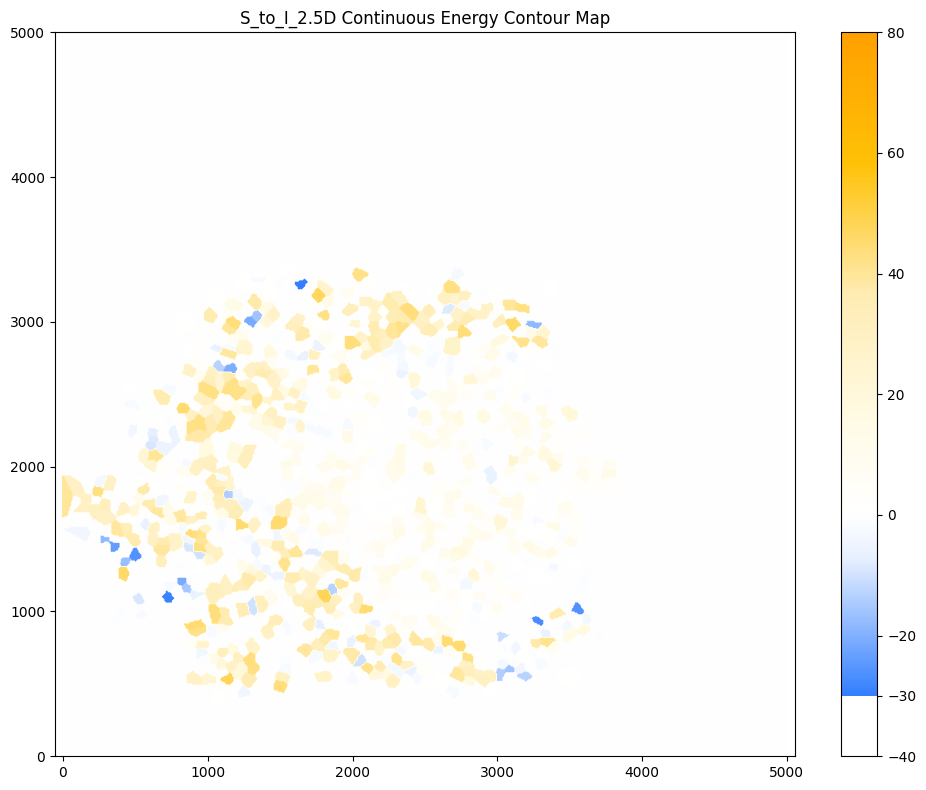

In [199]:
zi = zi_linear
# ------------------------------
# 4. Improved 2.5D contour plot (another view of a continuous field)
# ------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
colors = [
    (0.0, '#337fff'),                  # Dark blue (global min)
    (zero_pos-diff/2, '#e6efff'),      # Near white (before 0)
    (zero_pos, '#FFFFFF'),             # White (exactly 0)
    (zero_pos+diff, '#fffbe6'),      # Near white (after 0)
    (pos_index[1], '#ffecb3'),
    (pos_index[2], '#ffc107'),
    (1.0, '#ffa000')                   # Deep yellow (global max)
]
custom_cmap = LinearSegmentedColormap.from_list('custom_colormap', colors)
# Use more levels to make contours more continuous
contour = ax.contourf(xi, yi, zi,levels=200, cmap=custom_cmap,norm=Normalize(vmin=global_vmin, vmax=global_vmax))
# ax.scatter(x, y, c='black', s=node_sizes_3d, alpha=0.7, edgecolor='white', linewidth=0.3)
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=global_vmin, vmax=global_vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
auto_ticks = cbar.get_ticks()
custom_ticks = np.unique(np.concatenate([[global_vmin], auto_ticks, [global_vmax]]))
custom_ticks = np.sort(custom_ticks)
cbar.set_ticks(custom_ticks)

ax.set_title(f'{event_type}_2.5D Continuous Energy Contour Map')
ax.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(Path(OUTPUT_FILE_PATH).parent,f'{event_type}_Energy_Contour_Map.pdf'))
plt.show()

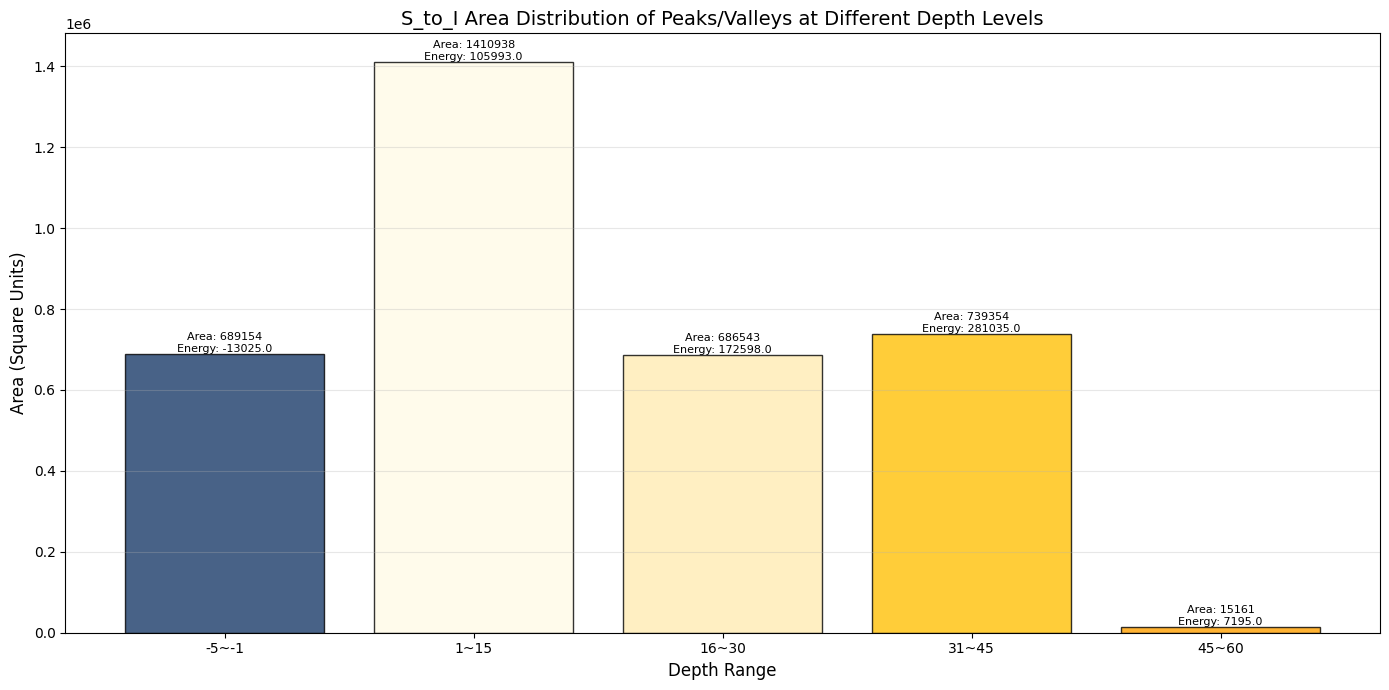

不同深度区间的面积分析：
区间 -5~-1: 面积 = 689154 平方单位, 总能量 = -13025.0
区间 1~15: 面积 = 1410938 平方单位, 总能量 = 105993.0
区间 16~30: 面积 = 686543 平方单位, 总能量 = 172598.0
区间 31~45: 面积 = 739354 平方单位, 总能量 = 281035.0
区间 45~60: 面积 = 15161 平方单位, 总能量 = 7195.0


In [200]:
# ------------------------------
# 1. Define depth intervals (adjusted to new requirements)
# ------------------------------
# Set depth range to -5~60; treat -1~1 as background
depth_bins = [-5, -1, 1, 15, 16, 30, 31, 45, 46, 60]  # Adjusted depth intervals
depth_labels = ['-5~-1', '1~15', '16~30', '31~45', '45~60']  # Corresponding interval labels (syntax fixed)

# Note: ensure xi, yi, and zi are already defined here
# Process data while excluding the -1~1 background range
zi[(zi > -1) & (zi < 1)] = np.nan # Move -1~1 values out of analysis range

# Compute grid-cell area
dx = np.mean(np.diff(xi, axis=1))  # Grid step along x
dy = np.mean(np.diff(yi, axis=0))  # Grid step along y
cell_area = dx * dy  # Area of one grid cell

# ------------------------------
# 2. Compute spatial density for each depth interval (excluding -1~1 background)
# ------------------------------
# Initialize result containers
spatial_densities = []  # Spatial density per interval (grid count / unit area)
area_per_depth = []     # Total area per interval
energy_sums = []        # Total energy per interval

# Adjust loop range to match new interval count
for i in range(len(depth_labels)):
    # Define current interval bounds
    lower = depth_bins[2*i]  # Adjust index for new interval partitioning
    upper = depth_bins[2*i + 1]
    
    # Select grids in current interval (automatically excludes -1~1 background)
    mask = (zi > lower) & (zi <= upper)
    
    # Compute grid count and total area for this interval
    grid_count = np.sum(mask)  # Total grid count in this interval
    total_area = grid_count * cell_area  # Total area in this interval
    energy_sum = np.sum(zi[mask])  # Total energy in this interval
    
    # Compute spatial density: grids per unit area (reflects compactness)
    density = grid_count / total_area if total_area != 0 else 0
    
    spatial_densities.append(density)
    area_per_depth.append(total_area)
    energy_sums.append(energy_sum)

# ------------------------------
# 3. Visualize spatial-density results
# ------------------------------
# Select colors matching the number of intervals from the colormap
colors = [
    '#1a3b69',  # Dark blue,  # Medium blue
    '#fffbe6',  # Light yellow
    '#ffecb3',  # Medium light yellow
    '#ffc107',  # Medium deep yellow
    '#ffa000'   # Deep yellow
]


plt.figure(figsize=(14, 7))

# Plot area bar chart
bars = plt.bar(depth_labels, area_per_depth, color=colors, edgecolor='black', alpha=0.8)

# Annotate bars with area and total energy
for bar, area, energy in zip(bars, area_per_depth, energy_sums):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,  # Adjust offset for area value range
             f'Area: {area:.0f}\nEnergy: {energy:.1f}',
             ha='center', va='bottom', fontsize=8)

# Add labels and title
plt.xlabel('Depth Range', fontsize=12)
plt.ylabel('Area (Square Units)', fontsize=12)  # Y-axis uses area units
plt.title(f'{event_type} Area Distribution of Peaks/Valleys at Different Depth Levels', fontsize=14)  # Title focuses on area distribution
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------
# 4. Output numeric results
# ------------------------------
print("Area analysis across depth intervals:")
for label, area, energy in zip(depth_labels, area_per_depth, energy_sums):
    print(f"Interval {label}: area = {area:.0f} square units, total energy = {energy:.1f}")


In [201]:
cell_types

array([1, 1, 1, ..., 4, 4, 4], dtype=int64)


⚙️  使用显著值进行矩阵二值化...
✅ 二值化完成！网络共包含97417条有效连接


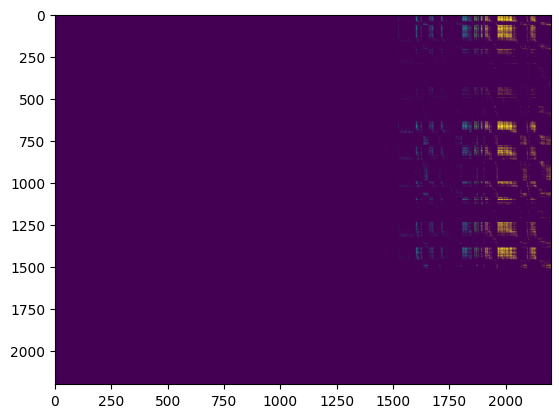

In [202]:
# Count key cells
adjacency_matrix = binarize_matrix(data.values,mask_2d)
weighted_adj = np.zeros((n_neurons, n_neurons))  # Initialize weighted adjacency matrix

for i in range(n_neurons):
    for j in range(i, n_neurons):  # For undirected graph, process only upper triangle
        if i == j:
            weighted_adj[i, j] = 0  # Self-connection is 0
            continue
        
        # Only set weights for significant edges 
        if adjacency_matrix[i, j] != 1:
            continue 
            
        # Set weights based on cell types
        type_i = cell_types[i]
        type_j = cell_types[j]
        
        if (type_i == 1 and type_j == 2) :
            weighted_adj[i, j] = 2
        elif (type_i == 1 and type_j == 4):
            weighted_adj[i, j] = 4
        elif (type_i == 1 and type_j == 3):
            weighted_adj[i, j] = 3
        else:
            weighted_adj[i, j] = 0

plt.imshow(weighted_adj, cmap='viridis',aspect='auto')


In [203]:
edge_counts = []
for i,cell in enumerate(cellnames):
    if cell == 'CamkII_TST':
        continue
    count = np.sum(weighted_adj == (i+1))
    print(f'CamkII ⇄ {cell} connections count: {count}')
    edge_counts.append({'cell_type': cell, 'count': count})
edge_counts = pd.DataFrame(edge_counts)
edge_counts.to_csv(os.path.join(os.path.dirname(OUTPUT_FILE_PATH), f'{event_type}_CamkII_edge_counts.csv'), index=False)


CamkII ⇄ PV connections count: 15399
CamkII ⇄ SST connections count: 4165
CamkII ⇄ VIP connections count: 25489
